Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

First 5 Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm) 

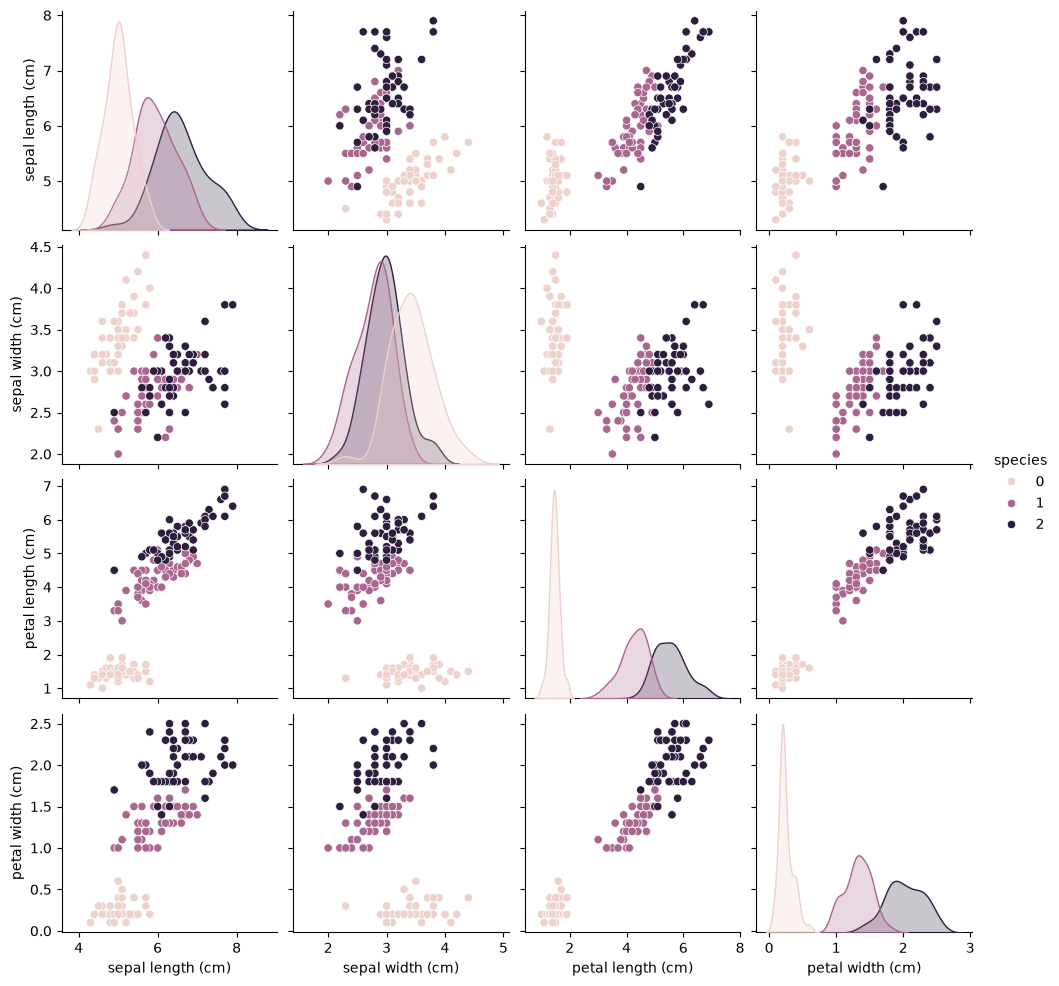


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)

Model Training Completed!

Accuracy:
1.0

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


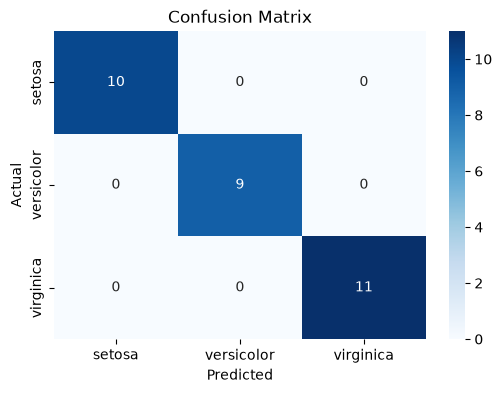


Prediction for Sample Flower:
setosa


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------
# Step 1: Load Dataset
# ------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

# ------------------------------------------------
# Step 2: Convert to DataFrame
# ------------------------------------------------

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

print("\nFirst 5 Records:")
print(df.head())

# ------------------------------------------------
# Step 3: Dataset Information
# ------------------------------------------------

print("\nDataset Information")
print(df.info())

print("\nDataset Statistics")
print(df.describe())

# ------------------------------------------------
# Step 4: Visualize Dataset
# ------------------------------------------------

sns.pairplot(
    pd.DataFrame(
        iris.data,
        columns=iris.feature_names
    ).assign(species=iris.target),
    hue="species"
)

plt.show()

# ------------------------------------------------
# Step 5: Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ------------------------------------------------
# Step 6: Create Random Forest Model
# ------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# ------------------------------------------------
# Step 7: Train Model
# ------------------------------------------------

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ------------------------------------------------
# Step 8: Prediction
# ------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------
# Step 9: Accuracy
# ------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

# ------------------------------------------------
# Step 10: Classification Report
# ------------------------------------------------

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# ------------------------------------------------
# Step 11: Confusion Matrix
# ------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# ------------------------------------------------
# Step 12: Visualize Confusion Matrix
# ------------------------------------------------

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ------------------------------------------------
# Step 13: Test Custom Flower
# ------------------------------------------------

sample_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample_flower)

print("\nPrediction for Sample Flower:")

print(
    iris.target_names[
        prediction[0]
    ]
)